In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
pd.options.display.max_rows = 999
pd.options.display.max_columns = 90

# Loading sql

In [2]:
con = sqlite3.connect('gas_monitoring.db')

In [3]:
cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]


In [4]:
query = "SELECT * FROM gas_monitoring"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

# Initial Analysis

### Target Column: Temperature

In [6]:
display(df['Temperature'].describe())
df[df['Temperature'] > 100]

,Temperature
count,10000.000000
mean,42.243124
std,73.974956
min,6.903485
25%,18.937500
50%,20.510000
75%,23.172500
max,307.070000


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
42,afternoon,293.81,49.07,74.411945,620.217312,399.022768,753.892766,705.797216,624.878193,1.0,7241,eco_mode,bright,High Activity
43,afternoon,295.10,47.17,78.710400,565.693739,520.455398,761.671720,713.629882,661.187642,0.0,4703,heating_active,moderate,Moderate Activity
90,evening,296.98,49.94,107.094146,600.834256,433.617367,742.350422,677.251205,613.420451,1.0,7241,off,moderate,High Activity
106,evening,297.30,48.34,110.552913,605.145553,437.118871,727.891895,671.712921,602.391350,2.0,7241,eco_mode,None,Moderate Activity
108,evening,297.91,48.51,120.220801,599.237428,407.045481,719.665665,655.334968,570.877422,2.0,7241,ventilation_only,very_dim,Low Activity


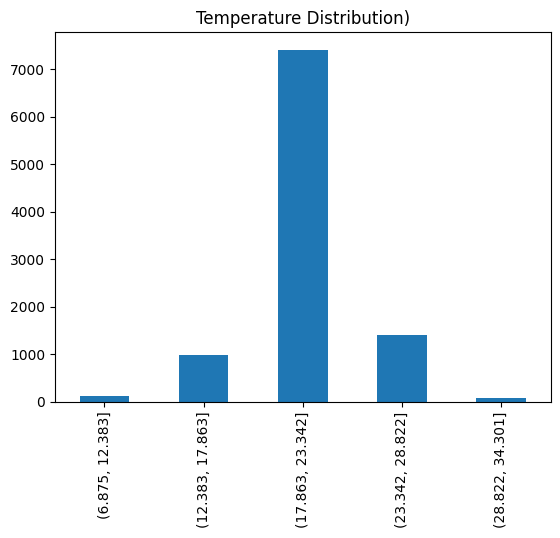

In [19]:
df['Temperature'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('Temperature Distribution)')
plt.show()

### Humidity

In [8]:
display(df['Humidity'].describe())
display(df['Humidity'].isna().sum() / df.shape[0])
df[df['Humidity'] < 0]

,Humidity
count,8072.000000
mean,51.643609
std,21.333894
min,-49.870000
25%,47.660000
50%,51.390000
75%,53.840000
max,198.900000


np.float64(0.1928)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9,night,19.810000,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
120,night,18.570000,-14.79,121.184923,579.703970,468.239926,NaN,678.065464,620.466497,1.0,2679,cooling_active,very_bright,Moderate Activity
146,night,19.690000,-18.73,120.017584,549.422635,459.086470,692.412305,645.741758,571.745341,2.0,7058,off,bright,Low Activity
214,night,19.670000,-4.01,235.217715,600.656020,473.844566,729.094245,686.763442,606.800807,2.0,7241,eco_mode,very_bright,Low Activity
282,morning,20.090000,-35.48,94.681893,608.264815,511.404061,759.890965,714.800339,647.422277,1.0,3856,maintenance_mode,very_bright,Moderate Activity
314,afternoon,19.920000,-3.44,66.259508,619.804128,550.239471,776.672154,744.301505,672.195693,0.0,3856,HEATING_ACTIVE,moderate,Moderate Activity
335,morning,17.220000,-49.87,207.966266,581.456914,498.282281,740.936450,701.413862,639.873640,1.0,2679,off,bright,Moderate Activity
489,afternoon,18.590000,-44.30,76.004016,576.693498,541.079818,752.677561,719.166414,661.696568,NaN,2847,cooling_active,dim,Low Activity
534,morning,19.080000,-43.56,102.745796,602.036350,489.720394,733.325098,675.358312,606.899771,1.0,3856,MAINTENANCE_MODE,moderate,Moderate Activity
621,afternoon,297.830000,-15.50,97.071508,606.209951,463.731986,742.921479,696.513108,644.773915,1.0,9127,MAINTENANCE_MODE,moderate,Moderate Activity


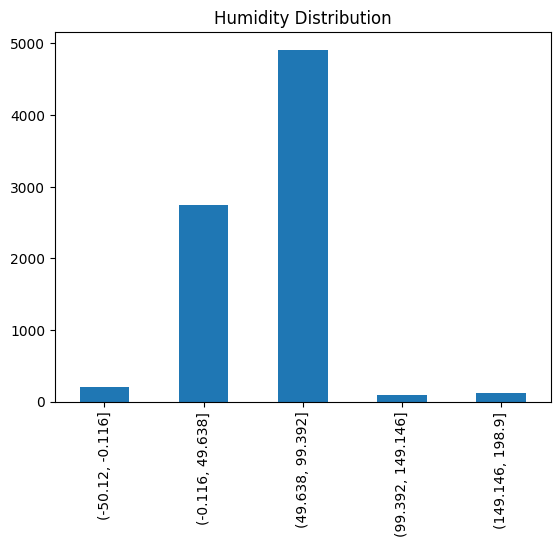

In [9]:
df['Humidity'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('Humidity Distribution')
plt.show()

### C02 Sensor

In [10]:
display(df[['CO2_InfraredSensor']].describe())

,CO2_InfraredSensor
count,10000.000000
mean,109.864352
std,33.793851
min,-17.472184
25%,96.660377
50%,112.807103
75%,124.540226
max,237.873938


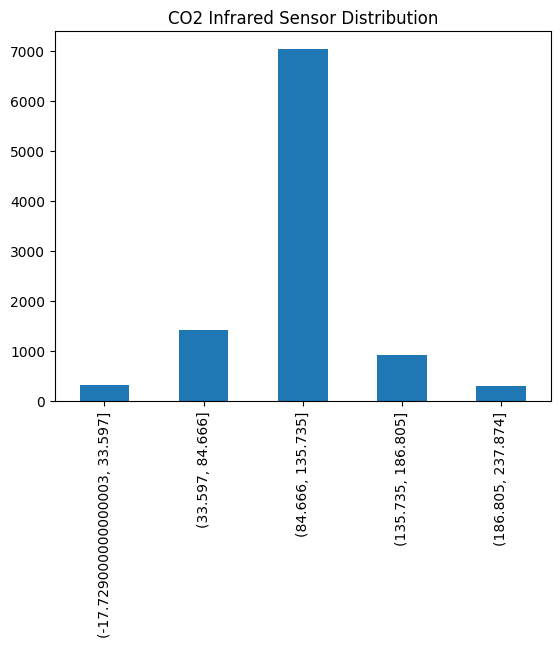

In [11]:
df['CO2_InfraredSensor'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('CO2 Infrared Sensor Distribution')
plt.show()

# Column by Column Data Cleaning

### Temperature

In [12]:
# Replace unrealistic Temperature values (> 60°C) with NaN
df.loc[df['Temperature'] > 60, 'Temperature'] = np.nan
temp_median = df['Temperature'].median()
df['Temperature'] = df['Temperature'].fillna(temp_median)

In [13]:
display(df['Temperature'].describe())

,Temperature
count,10000.000000
mean,20.495026
std,2.740635
min,6.903485
25%,18.937500
50%,20.200000
75%,22.342500
max,34.301271


In [14]:
display(df['Temperature'].isna().sum())

np.int64(0)

### Humidity

In [15]:
# Replace negative Humidity values with NaN (physically impossible)
df.loc[df['Humidity'] < 0, 'Humidity'] = np.nan
humidity_median = df['Humidity'].median()
df['Humidity'] = df['Humidity'].fillna(humidity_median)

In [16]:
display(df['Humidity'].describe())

,Humidity
count,10000.000000
mean,53.174511
std,15.661224
min,39.690000
25%,49.190000
50%,51.570000
75%,53.200000
max,198.900000


In [17]:
display(df['Humidity'].isna().sum())

np.int64(0)